# Detector perro vs no-perro — **PyTorch** (CNN desde cero)

Misma arquitectura y dataset que la versión TensorFlow, para comparar.
Ejecuta en orden (o **Run All**).


In [2]:
# 1) Dependencias
#%pip install -r requirements.txt
import importlib
for pkg in ['torch', 'torchvision', 'sklearn', 'numpy', 'matplotlib', 'PIL']:
    mod = importlib.import_module(pkg)
    print(f'{pkg}: {getattr(mod, "__version__", "ok")}')
import torch
print('CUDA disponible:', torch.cuda.is_available())

  Using cached matplotlib-3.11.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (80 kB)
  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached torch-2.12.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached torchvision-0.27.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached keras-3.15.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached nvidia_cudnn_cu13-9.20.0.48-py3-none-manylinux_2_27_x86_64.whl.metadata (1.9 kB)
  Using cached nvidia_cusolver-12.0.4.66-py3-none-manylinux_2_27_x86_64.whl.metadata (1.8 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
Using cached matplotlib-3.11.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.0 MB)
Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl (572.6 MB)
Using cached torch-2.12.1-cp312-cp312-manylinux_2_28_x86_64.whl 

In [3]:
# 2) Dataset (el mismo que TF; idempotente)
import dataset
dataset.build()

[dataset] descarga ya presente: /mnt/c/Users/gotts/AI-Frameworks/data/downloads/kagglecatsanddogs.zip
[dataset] copiando 4000 perros y 4000 gatos...


/mnt/c/Users/gotts/AI-Frameworks/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
validando dog:  85%|████████▌ | 3416/4000 [01:54<00:26, 22.06it/s]/mnt/c/Users/gotts/AI-Frameworks/venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
validando not_dog: 100%|██████████| 4000/4000 [03:02<00:00, 21.97it/s]


[dataset] conteos finales: {'dog': 3999, 'not_dog': 3999}


{'dog': 3999, 'not_dog': 3999}

In [11]:
# 3) Entrenamiento de la CNN desde cero (PyTorch)
import train_torch
results = train_torch.run(epochs=5)

PyTorch: 2.12.1+cu130 | device: cuda
Clases: ['dog', 'not_dog']


KeyboardInterrupt: 

Clases: ['dog', 'not_dog']
Matriz de confusión:
[[322 488]
 [ 84 705]]
Accuracy: 0.6423 | AUC: 0.7474


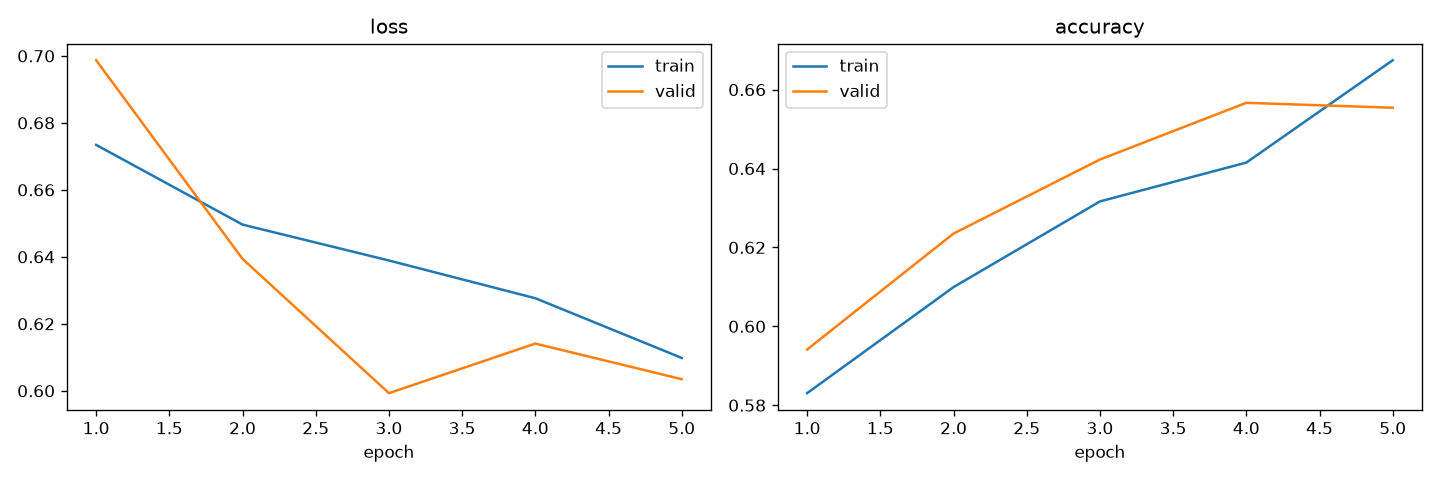

In [10]:
# 4) Resultados
print('Clases:', results['class_names'])
print('Matriz de confusión:'); print(results['confusion_matrix'])
print(f"Accuracy: {results['accuracy']:.4f} | AUC: {results['auc']:.4f}")
from IPython.display import Image
Image(filename='artifacts/dog_detector_torch_history.png')

In [14]:
from pathlib import Path
import matplotlib.pyplot as plt

confusion_matrix = results['confusion_matrix']
class_names = results['class_names']
confusion_matrix_path = Path.cwd() / 'artifacts' / 'dog_detector_torch_confusion_matrix.png'
confusion_matrix_path.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(confusion_matrix, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión')
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        ax.text(j, i, str(confusion_matrix[i, j]), ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(confusion_matrix_path, dpi=120)
plt.show()
plt.close(fig)
print('Matriz de confusión guardada en', confusion_matrix_path)

Matriz de confusión guardada en /mnt/c/Users/gotts/AI-Frameworks/artifacts/dog_detector_torch_confusion_matrix.png


/tmp/ipykernel_1203/2156980179.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [1]:
# 5) Inferencia sobre una imagen nueva
from pathlib import Path
from PIL import Image
import torch
from torchvision import transforms
import train_torch

inference_device = train_torch.DEVICE
inference_model = train_torch.DogDetector(train_torch.CONFIG.dropout).to(inference_device)
inference_model.load_state_dict(torch.load(train_torch.MODEL_PATH, map_location=inference_device))
inference_model.eval()

inference_transform = transforms.Compose([
    transforms.Resize((train_torch.CONFIG.image_size, train_torch.CONFIG.image_size)),
    transforms.ToTensor(),
])

def predict_image(image_path):
    image_path = Path(image_path)
    image = Image.open(image_path).convert('RGB')
    tensor = inference_transform(image).unsqueeze(0).to(inference_device)
    with torch.no_grad():
        logit = inference_model(tensor)
        prob = torch.sigmoid(logit).item()
    label_index = int(prob >= 0.5)
    class_names = ['not_dog', 'dog']
    label = class_names[label_index]
    print(f'Imagen: {image_path}')
    print(f'Probabilidad de dog: {prob:.4f}')
    print(f'Resultado: {label}')
    return {'image_path': str(image_path), 'prob_dog': prob, 'label': label}

# Cambia esta ruta por tu foto
sample_image_path = 'Perro1.jpg'
predict_image(sample_image_path)

Imagen: Perro1.jpg
Probabilidad de dog: 0.6068
Resultado: dog


{'image_path': 'Perro1.jpg', 'prob_dog': 0.6068276166915894, 'label': 'dog'}